# NextGen Hydrofabric Conflation Visual QA — Texas eBFE Shiloh Branch

This notebook performs a real-data visual review of
`RasHydrofabric.conflate()` using the **Lower Colorado–Cummins** Texas
eBFE/BLE delivery (HUC8 `12090301`) and its 1D **SHILOH BRANCH** reach. It
compares the HEC-RAS footprint, river centerline, and 40 cross sections with
native NextGen v2.2 flowpaths and catchments, then exposes every score
component used to resolve the match.

## What you will verify

- Model footprint, centerline, XS cut lines, flowpaths, and HUC12 boundaries
  align in one projected CRS.
- Candidate rank reflects overlap, distance, direction, XS intersections,
  topology, stream scale, and sequence evidence.
- Accepted links retain `feature_id`, confidence, reasons, and measures.
- A deliberately strict sensitivity run exposes `matched`, `ambiguous`, and
  `unmatched` states without fake accepted COMIDs.

The model is obtained through `RasEbfeModels`. The network is the public
[CIROH NextGen v2.2 VPU 12 geopackage](https://ciroh-community-ngen-datastream.s3.amazonaws.com/resources/v2.2_hydrofabric/geopackages/VPU_12/nextgen_VPU_12.gpkg),
used by the [NextGen Research Datastream](https://github.com/CIROH-UA/ngen-datastream/blob/main/docs/nrds/DATASTREAMS.md).
HUC12 reporting polygons come independently from the
[USGS Watershed Boundary Dataset](https://apps.nationalmap.gov/downloader/).

> The thresholds here are visual-QA parameters, not ras2fim or production
> acceptance policy. The strict run is intentionally conservative.


In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True

import logging
import os
import sys
from pathlib import Path
from xml.etree import ElementTree as ET
from zipfile import ZipFile

if USE_LOCAL_SOURCE:
    here = Path.cwd().resolve()
    repo_root = next(
        (p for p in [here, *here.parents] if (p / "ras_commander" / "__init__.py").exists()),
        here,
    )
    sys.path.insert(0, str(repo_root))
    print("LOCAL SOURCE MODE:", repo_root)
else:
    repo_root = Path.cwd().resolve()
    print("PIP PACKAGE MODE")

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pyproj import CRS

import ras_commander
from ras_commander import HdfProject, HdfXsec, RasCmdr, RasHydrofabric, RasPlan, init_ras_project
from ras_commander.sources.federal import RasEbfeModels

logging.getLogger("ras_commander").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})
working_dir = repo_root / "working" / "example_956_hydrofabric_conflation"
working_dir.mkdir(parents=True, exist_ok=True)
print("ras-commander:", ras_commander.__file__)
print("Working cache:", working_dir)


LOCAL SOURCE MODE: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate


ras-commander: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate\ras_commander\__init__.py
Working cache: \\192.168.3.20\CLB-Engineering\Symphony\ras-commander\hydrofabric-conflate\working\example_956_hydrofabric_conflation


## 1. Reuse or organize the Texas eBFE model

Lower Colorado–Cummins is a Texas 1D steady BLE reach collection. SHILOH
BRANCH is compact enough for legible maps while providing 40 independent XS
checks. The organizer downloads the archive only when it is absent.


In [2]:
BLE_RIVER = "Rabbs Creek-Colorado River"
BLE_REACH_NAME = "SHILOH BRANCH"
RAS_VERSION = "7.0"
EBFE_WORKSPACE = Path(os.environ.get(
    "RAS_COMMANDER_EBFE_ROOT", r"H:\Testing\eBFE Model Organization"
))
DOWNLOAD_ROOT = EBFE_WORKSPACE / "Downloads"
ORGANIZED_ROOT = EBFE_WORKSPACE / "Organized"
organized = ORGANIZED_ROOT / "LowerColoradoCummins_12090301"
project_folder = organized / "RAS Model" / BLE_RIVER / BLE_REACH_NAME

if not (project_folder / f"{BLE_REACH_NAME}.prj").exists():
    organized = RasEbfeModels.organize_model(
        "lower-colorado-cummins", download_root=DOWNLOAD_ROOT,
        output_root=ORGANIZED_ROOT, river=BLE_RIVER, reach=BLE_REACH_NAME,
    )
    project_folder = organized / "RAS Model" / BLE_RIVER / BLE_REACH_NAME

print("Organized study:", organized)
print("Project folder:", project_folder)


Organized study: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301
Project folder: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301\RAS Model\Rabbs Creek-Colorado River\SHILOH BRANCH


The original BLE project predates geometry-HDF output. A migrated HDF is
reused when present. On a fresh Windows workspace, ras-commander enables the
necessary run flags and computes the steady plan with HEC-RAS 7.0.


In [3]:
GENERATE_HDF_IF_MISSING = True
ras = init_ras_project(project_folder, RAS_VERSION)
geom_hdf = project_folder / f"{ras.project_name}.g01.hdf"
if not geom_hdf.exists():
    if not GENERATE_HDF_IF_MISSING:
        raise FileNotFoundError(f"Set GENERATE_HDF_IF_MISSING=True to create {geom_hdf.name}")
    RasPlan.update_run_flags(
        "01", geometry_preprocessor=True, post_processor=True, ras_object=ras
    )
    RasCmdr.compute_plan("01", ras_object=ras, force_geompre=True)
    ras = init_ras_project(project_folder, RAS_VERSION)
if not geom_hdf.exists():
    raise FileNotFoundError(f"HEC-RAS did not create {geom_hdf}")
print("Geometry HDF:", geom_hdf.name, f"({geom_hdf.stat().st_size:,} bytes)")


Geometry HDF: SHILOH BRANCH.g01.hdf (332,579 bytes)


## 2. Extract and identify HEC-RAS geometry

This legacy delivery stores its authoritative projection WKT in the vendor
XML rather than the HDF. We recover `EPSG:2277` (NAD83 / Texas Central ftUS),
assign it to the public HDF-reader outputs, and add stable IDs.


In [4]:
project_xml = project_folder / f"{ras.project_name}.xml"
projection_wkt = (ET.parse(project_xml).findtext("Projection") or "").strip()
model_crs = CRS.from_wkt(projection_wkt)
cross_sections = HdfXsec.get_cross_sections(geom_hdf).set_crs(model_crs, allow_override=True)
centerlines = HdfXsec.get_river_centerlines(geom_hdf).set_crs(model_crs, allow_override=True)
model_footprints, _ = HdfProject.get_project_extent(
    geom_hdf, geometry_type="footprint", include_2d=False, buffer_percent=0.0
)
model_footprints = model_footprints.set_crs(model_crs, allow_override=True)

geometry_id = "lower-colorado-cummins-shiloh-branch"
model_footprints["geometry_id"] = geometry_id
centerlines["geometry_id"] = geometry_id
centerlines["reach_id"] = (
    centerlines["River Name"].astype(str).str.strip() + " / "
    + centerlines["Reach Name"].astype(str).str.strip()
)
cross_sections["geometry_id"] = geometry_id
cross_sections["reach_id"] = (
    cross_sections["River"].astype(str).str.strip() + " / "
    + cross_sections["Reach"].astype(str).str.strip()
)
cross_sections["xs_id"] = cross_sections["RS"].astype(str).str.strip()

model_summary = pd.DataFrame({
    "layer": ["model footprint", "river centerline", "cross sections"],
    "features": [len(model_footprints), len(centerlines), len(cross_sections)],
    "geometry_type": [", ".join(sorted(set(g.geom_type)))
                      for g in (model_footprints, centerlines, cross_sections)],
})
print("Model CRS:", model_crs.to_authority(), "—", model_crs.name)
display(model_summary)


Model CRS: ('EPSG', '2277') — NAD83 / Texas Central (ftUS)


,layer,features,geometry_type
0,model footprint,1,Polygon
1,river centerline,1,LineString
2,cross sections,40,LineString


## 3. Load NextGen v2.2 flowpaths, catchments, and HUC12 polygons

VPU 12 is downloaded once and cached under
`working/example_956_hydrofabric_conflation/`. Only flowpaths and divides
within 1,500 m of the HEC-RAS footprint are read into memory. The native
NextGen identifiers (`wb-*`, `cat-*`, and `nex-*`) are preserved. HUC12s are
a separate reporting layer read from the USGS HUC8 data archive.


In [5]:
NEXTGEN_URL = (
    "https://ciroh-community-ngen-datastream.s3.amazonaws.com/"
    "resources/v2.2_hydrofabric/geopackages/VPU_12/nextgen_VPU_12.gpkg"
)
WBD_HU8_URL = (
    "https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/NHD/HU8/"
    "GPKG/NHD_H_12090301_HU8_GPKG.zip"
)
REFRESH_SOURCES = False
nextgen_cache = working_dir / "nextgen_VPU_12_v2.2.gpkg"
wbd_archive = working_dir / "NHD_H_12090301_HU8_GPKG.zip"
wbd_cache = working_dir / "NHD_H_12090301_HU8_GPKG.gpkg"

def download_file(url, destination):
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        with destination.open("wb") as stream:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    stream.write(chunk)

if REFRESH_SOURCES or not nextgen_cache.exists():
    download_file(NEXTGEN_URL, nextgen_cache)
    nextgen_state = "downloaded and cached"
else:
    nextgen_state = "loaded from working cache"
if REFRESH_SOURCES or not wbd_cache.exists():
    download_file(WBD_HU8_URL, wbd_archive)
    with ZipFile(wbd_archive) as archive:
        archive.extract("NHD_H_12090301_HU8_GPKG.gpkg", working_dir)
    wbd_state = "downloaded and cached"
else:
    wbd_state = "loaded from working cache"

query_bounds_5070 = model_footprints.to_crs(5070).buffer(1500).total_bounds
flowpaths = gpd.read_file(
    nextgen_cache, layer="flowpaths", bbox=tuple(query_bounds_5070)
)
divides = gpd.read_file(
    nextgen_cache, layer="divides", bbox=tuple(query_bounds_5070)
)

query_bounds_4269 = model_footprints.to_crs(3857).buffer(1500).to_crs(4269).total_bounds
hucs = gpd.read_file(
    wbd_cache, layer="WBDHU12", bbox=tuple(query_bounds_4269)
)
flowpaths = flowpaths.loc[flowpaths.geometry.notna() & ~flowpaths.geometry.is_empty].copy()
divides = divides.loc[divides.geometry.notna() & ~divides.geometry.is_empty].copy()
hucs = hucs.loc[hucs.geometry.notna() & ~hucs.geometry.is_empty].copy()
print(f"NextGen v2.2 VPU 12 flowpaths: {len(flowpaths)} ({nextgen_state})")
print(f"NextGen catchments: {len(divides)}")
print(f"WBD HUC12 polygons: {len(hucs)} ({wbd_state})")
display(flowpaths[[
    "id", "toid", "order", "hydroseq", "areasqkm",
    "tot_drainage_areasqkm", "divide_id",
]].sort_values("hydroseq").reset_index(drop=True))
display(hucs[["huc12", "name"]].sort_values("huc12").reset_index(drop=True))


NextGen v2.2 VPU 12 flowpaths: 9 (loaded from working cache)
NextGen catchments: 12
WBD HUC12 polygons: 3 (loaded from working cache)


,id,toid,order,hydroseq,areasqkm,tot_drainage_areasqkm,divide_id
0,wb-2430631,nex-2430632,6.0,12023,11.194199,94312.085537,cat-2430631
1,wb-2430630,nex-2430631,6.0,12024,26.901002,94277.320338,cat-2430630
2,wb-2430628,nex-2430629,6.0,12027,10.705950,94229.803038,cat-2430628
3,wb-2437147,nex-2437142,3.0,12056,11.803050,99.387451,cat-2437147
4,wb-2430904,nex-2430902,1.0,18551,11.745899,16.536600,cat-2430904
5,wb-2430903,nex-2430904,1.0,18552,4.790700,4.790700,cat-2430903
6,wb-2430902,nex-2430631,1.0,18553,7.034400,7.034400,cat-2430902
7,wb-2437184,nex-2430632,1.0,18555,9.503551,9.503551,cat-2437184
8,wb-2437189,nex-2437190,1.0,18586,10.539451,10.539451,cat-2437189


,huc12,name
0,120903010503,Little Pin Oak Creek
1,120903010506,Lower Rabbs Creek
2,120903010507,Cedar Creek-Colorado River


### Source-data alignment map

First verify that the model and hydrofabric occupy the same corridor. The
blue network and green catchments are the native NextGen layers; black and
gray are HEC-RAS geometry. The tan HUC12 boundary is reporting context only.


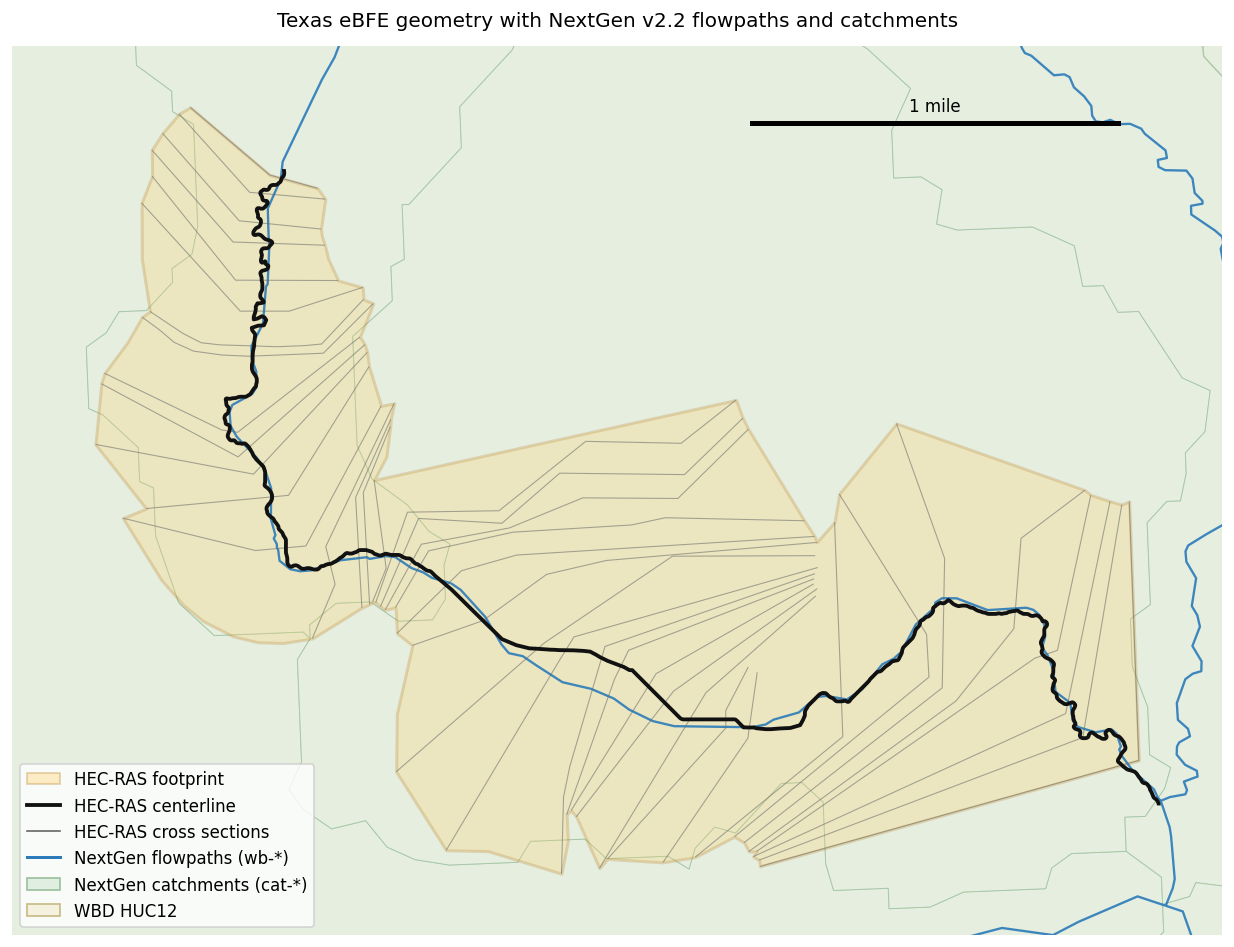

In [6]:
flowpaths_model = flowpaths.to_crs(model_crs)
divides_model = divides.to_crs(model_crs)
hucs_model = hucs.to_crs(model_crs)
fig, ax = plt.subplots(figsize=(11, 8))
hucs_model.plot(ax=ax, color="#f4f1de", edgecolor="#c7b983", linewidth=1)
divides_model.plot(ax=ax, color="#dfeee0", edgecolor="#9bbf9d", linewidth=.55, alpha=.7)
flowpaths_model.plot(ax=ax, color="#2b7bba", linewidth=1.4, alpha=.9)
model_footprints.plot(ax=ax, color="#ffd166", edgecolor="#b7791f", lw=1.8, alpha=.25)
cross_sections.plot(ax=ax, color="#666666", linewidth=.65, alpha=.55)
centerlines.plot(ax=ax, color="#111111", linewidth=2.3)
xmin, ymin, xmax, ymax = model_footprints.total_bounds
xp, yp = (xmax-xmin)*.08, (ymax-ymin)*.08
ax.set(xlim=(xmin-xp, xmax+xp), ylim=(ymin-yp, ymax+yp), aspect="equal")
sx, sy = xmax-5280-xp*.25, ymax-yp*.25
ax.plot([sx, sx+5280], [sy, sy], color="black", lw=3)
ax.text(sx+2640, sy+yp*.12, "1 mile", ha="center", va="bottom")
ax.set_axis_off()
ax.set_title("Texas eBFE geometry with NextGen v2.2 flowpaths and catchments", pad=12)
ax.legend(handles=[
    Patch(facecolor="#ffd166", edgecolor="#b7791f", alpha=.35, label="HEC-RAS footprint"),
    Line2D([0],[0], color="#111111", lw=2.3, label="HEC-RAS centerline"),
    Line2D([0],[0], color="#666666", lw=1, label="HEC-RAS cross sections"),
    Line2D([0],[0], color="#2b7bba", lw=1.8, label="NextGen flowpaths (wb-*)"),
    Patch(facecolor="#dfeee0", edgecolor="#9bbf9d", label="NextGen catchments (cat-*)"),
    Patch(facecolor="#f4f1de", edgecolor="#c7b983", label="WBD HUC12"),
], loc="lower left")
plt.tight_layout()
plt.show()


## 4. Run multi-criteria conflation

The NextGen adapter preserves `wb-*` feature IDs and normalizes the `nex-*`
downstream link, stream order, drainage area, and hydrosequence. HUC
intersections are reporting evidence and do not influence the candidate score.


In [7]:
result = RasHydrofabric.conflate(
    model_footprints, centerlines, cross_sections, flowpaths,
    adapter="nextgen", hucs=hucs, huc_id_col="huc12",
    max_candidates=8, min_confidence=.55, ambiguity_margin=.05,
)
status_order = ["matched", "ambiguous", "unmatched"]
status_by_element = pd.crosstab(result.matches.element_type, result.matches.status)
status_by_element = status_by_element.reindex(columns=status_order, fill_value=0)
status_by_element["total"] = status_by_element.sum(axis=1)
print("Adapter:", result.adapter, "| Analysis CRS:", result.analysis_crs)
print("Parameters:", result.parameters)
display(status_by_element)

reach_match = result.matches.loc[result.matches.element_type == "reach"].iloc[0]
reach_candidates = result.candidates.loc[
    result.candidates.element_type == "reach"
].sort_values("candidate_rank").copy()
print(f"Accepted reach feature: {reach_match.feature_id}; "
      f"confidence={reach_match.confidence_score:.3f}; margin={reach_match.score_margin:.3f}")
display(reach_candidates[[
    "candidate_rank", "feature_id", "confidence_score", "centerline_mean_distance",
    "angular_difference_deg", "xs_intersection_count", "xs_total_count",
    "stream_order", "drainage_area", "reason_codes",
]].reset_index(drop=True))


Adapter: nextgen | Analysis CRS: EPSG:2277
Parameters: {'weights': {'footprint_overlap': 0.15, 'centerline_distance': 0.2, 'direction_agreement': 0.12, 'xs_intersections': 0.18, 'topological_continuity': 0.15, 'stream_order_drainage_area': 0.1, 'sequence_consistency': 0.1}, 'search_distance': 6322.941270214319, 'topology_tolerance': 505.83530161714555, 'max_candidates': 8, 'min_confidence': 0.55, 'ambiguity_margin': 0.05, 'sample_count': 9}


status,matched,ambiguous,unmatched,total
element_type,,,,
cross_section,40,0,0,40
geometry,1,0,0,1
reach,1,0,0,1


Accepted reach feature: wb-2430904; confidence=0.726; margin=0.167


,candidate_rank,feature_id,confidence_score,centerline_mean_distance,angular_difference_deg,xs_intersection_count,xs_total_count,stream_order,drainage_area,reason_codes
0,1,wb-2430904,0.725701,942.425123,20.638119,18,40,1.0,11.745899,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
1,2,wb-2430903,0.558744,2398.982525,62.216023,22,40,1.0,4.790700,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
2,3,wb-2430630,0.315274,6475.097206,61.854127,0,40,6.0,26.901002,"(HYDROLOGIC_SCALE_SUPPORTED,)"
3,4,wb-2430902,0.292629,6098.493153,37.340342,0,40,1.0,7.034400,"(DIRECTION_ALIGNED, SEQUENCE_CONSISTENT)"
4,5,wb-2430631,0.265437,8989.302952,28.280671,0,40,6.0,11.194199,"(DIRECTION_ALIGNED,)"
5,6,wb-2437184,0.249751,10004.162288,3.082776,0,40,1.0,9.503551,"(DIRECTION_ALIGNED,)"


### Candidate map and direct XS evidence

Red and purple points mark exact XS intersections with the two adjacent
leading candidates. Together they show why a single HEC-RAS reach can map to
a sequence of shorter NextGen flowpaths. Ranks 3–8 remain visible for review.


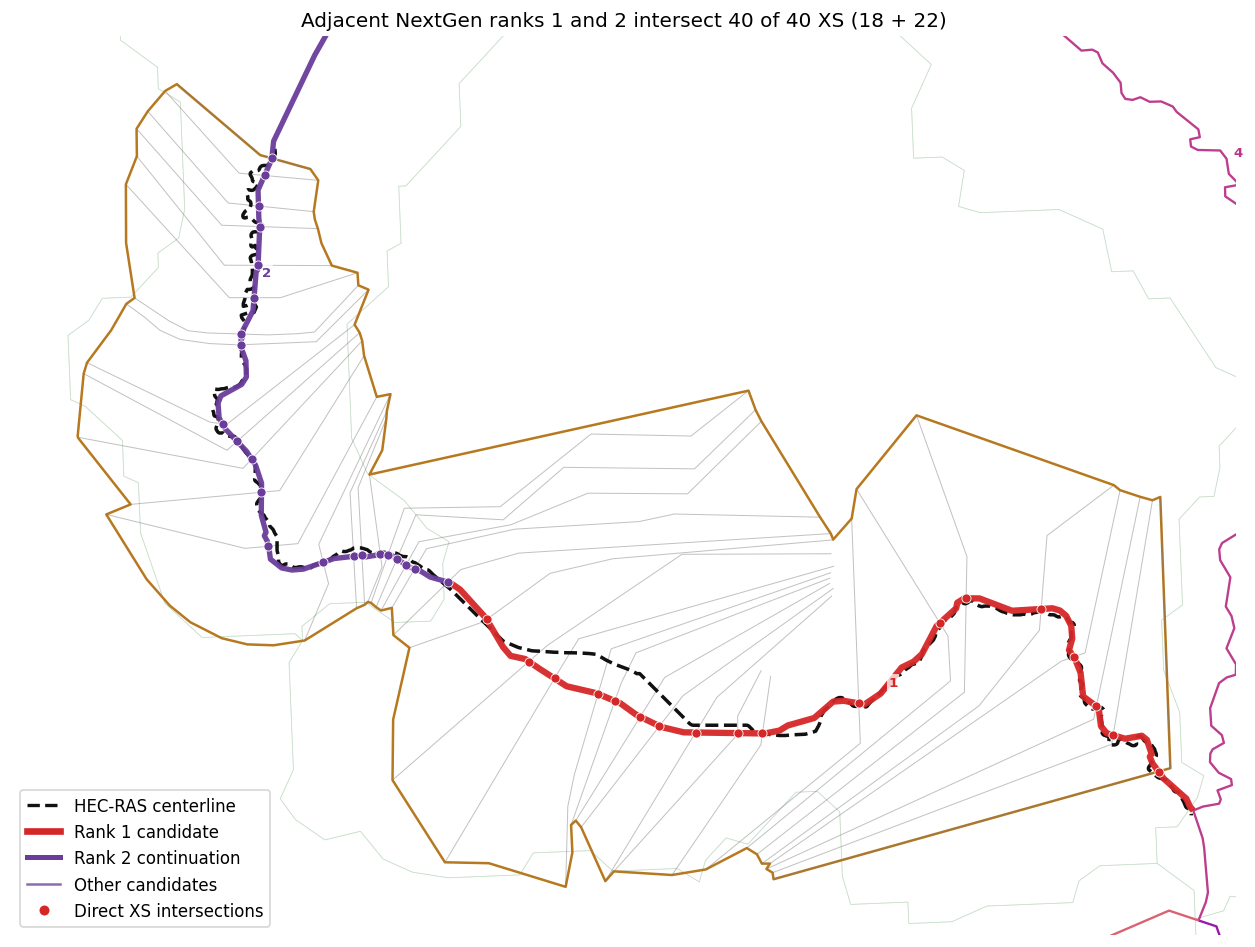

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
divides_model.boundary.plot(ax=ax, color="#bdd7bf", linewidth=.45, alpha=.6)
flowpaths_model.plot(ax=ax, color="#d8e8f0", linewidth=.8, alpha=.8)
model_footprints.boundary.plot(ax=ax, color="#b7791f", linewidth=1.5)
cross_sections.plot(ax=ax, color="#777777", linewidth=.6, alpha=.45)
centerlines.plot(ax=ax, color="#111111", linewidth=2.1, linestyle="--")
colors = plt.cm.plasma_r(np.linspace(.18, .82, len(reach_candidates)))
for color, (_, candidate) in zip(colors[::-1], reach_candidates.iloc[::-1].iterrows()):
    rank = int(candidate.candidate_rank)
    if rank == 1:
        line_color, width = "#d62728", 3.8
    elif rank == 2:
        line_color, width = "#6a3d9a", 3.2
    else:
        line_color, width = color, 1.4
    gpd.GeoSeries([candidate.geometry], crs=result.analysis_crs).plot(
        ax=ax, color=line_color, linewidth=width, alpha=.95
    )
    midpoint = candidate.geometry.interpolate(.5, normalized=True)
    ax.annotate(str(rank), (midpoint.x, midpoint.y), xytext=(4,4),
                textcoords="offset points", fontsize=8, weight="bold", color=line_color,
                bbox={"facecolor":"white", "edgecolor":"none", "alpha":.75, "pad":1})
top_flowpath = reach_candidates.iloc[0].geometry
top_two_counts = []
for rank, point_color in [(1, "#d62728"), (2, "#6a3d9a")]:
    candidate_geometry = reach_candidates.iloc[rank - 1].geometry
    intersections = cross_sections.geometry.intersection(candidate_geometry)
    points = gpd.GeoDataFrame(
        geometry=intersections.loc[~intersections.is_empty], crs=model_crs
    ).explode(index_parts=False)
    points = points.loc[points.geom_type.isin(["Point", "MultiPoint"])]
    top_two_counts.append(len(points))
    points.plot(
        ax=ax, color=point_color, edgecolor="white", linewidth=.5,
        markersize=30, zorder=8,
    )
xmin, ymin, xmax, ymax = model_footprints.total_bounds
xp, yp = (xmax-xmin)*.06, (ymax-ymin)*.06
ax.set(xlim=(xmin-xp,xmax+xp), ylim=(ymin-yp,ymax+yp), aspect="equal")
ax.set_axis_off()
ax.set_title(
    f"Adjacent NextGen ranks 1 and 2 intersect {sum(top_two_counts)} of "
    f"{int(reach_candidates.iloc[0].xs_total_count)} XS "
    f"({top_two_counts[0]} + {top_two_counts[1]})"
)
ax.legend(handles=[
    Line2D([0],[0], color="#111111", lw=2, ls="--", label="HEC-RAS centerline"),
    Line2D([0],[0], color="#d62728", lw=4, label="Rank 1 candidate"),
    Line2D([0],[0], color="#6a3d9a", lw=3, label="Rank 2 continuation"),
    Line2D([0],[0], color="#8c6bb1", lw=1.5, label="Other candidates"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor="#d62728",
           markeredgecolor="white", markersize=7, label="Direct XS intersections"),
], loc="lower left")
plt.tight_layout()
plt.show()


### Score-component audit

Gray means evidence unavailable and its weight was renormalized away. A
one-reach model has no model-to-model topology neighbor, so that column is n/a.


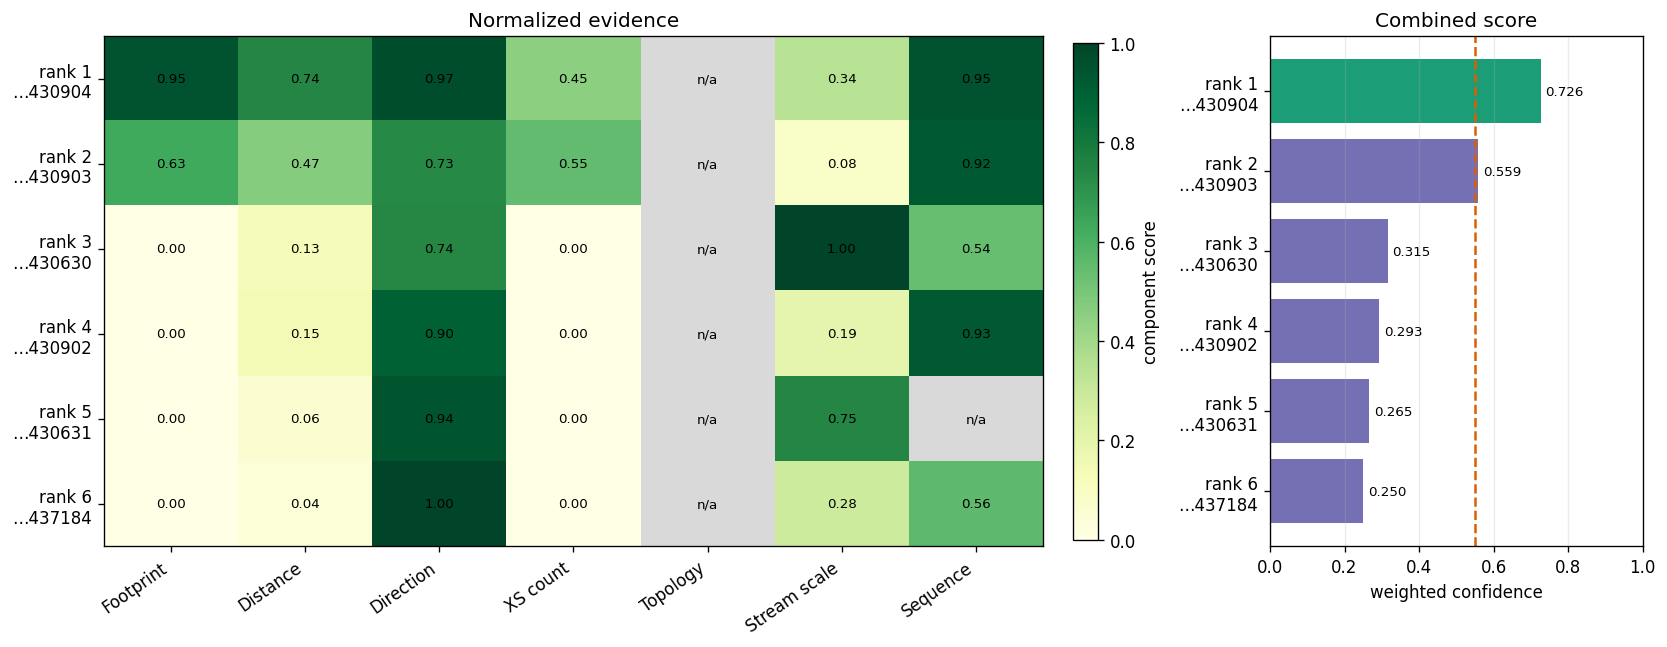

In [9]:
score_columns = [
    "footprint_overlap_score", "centerline_distance_score",
    "direction_agreement_score", "xs_intersection_score",
    "topological_continuity_score", "hydrologic_score",
    "sequence_consistency_score",
]
labels = ["Footprint","Distance","Direction","XS count","Topology","Stream scale","Sequence"]
view = reach_candidates.head(6)
matrix = view[score_columns].to_numpy(dtype=float)
ylabels = [f"rank {int(r)}\n…{str(fid)[-6:]}" for r,fid in zip(view.candidate_rank,view.feature_id)]
fig, (heat, total) = plt.subplots(1,2,figsize=(14,5.5),gridspec_kw={"width_ratios":[3.2,1.2]})
cmap = plt.cm.YlGn.copy()
cmap.set_bad("#d9d9d9")
image = heat.imshow(np.ma.masked_invalid(matrix), vmin=0, vmax=1, cmap=cmap, aspect="auto")
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        heat.text(j,i,"n/a" if np.isnan(matrix[i,j]) else f"{matrix[i,j]:.2f}",
                  ha="center",va="center",fontsize=8)
heat.set_xticks(range(len(labels)),labels,rotation=35,ha="right")
heat.set_yticks(range(len(ylabels)),ylabels)
heat.set_title("Normalized evidence")
fig.colorbar(image,ax=heat,fraction=.025,pad=.03,label="component score")
totals=view.confidence_score.to_numpy()
bars=total.barh(range(len(totals)),totals,color=["#1b9e77"]+["#7570b3"]*(len(totals)-1))
total.axvline(result.parameters["min_confidence"],color="#d95f02",ls="--",lw=1.5)
total.set_yticks(range(len(ylabels)),ylabels)
total.invert_yaxis()
total.set_xlim(0,1)
total.set_xlabel("weighted confidence")
total.set_title("Combined score")
total.bar_label(bars,labels=[f"{v:.3f}" for v in totals],padding=3,fontsize=8)
total.grid(axis="x",alpha=.25)
plt.tight_layout()
plt.show()


## 5. Inspect explicit ambiguous and unmatched states

The same evidence is re-resolved with `min_confidence=0.80` and
`ambiguity_margin=0.25`. Best candidates remain reviewable, but accepted
`feature_id` is null for every unresolved row.


In [10]:
strict_result = RasHydrofabric.conflate(
    model_footprints, centerlines, cross_sections, flowpaths,
    adapter="nextgen", hucs=hucs, huc_id_col="huc12",
    max_candidates=8, min_confidence=.80, ambiguity_margin=.25,
)
strict_status = pd.crosstab(strict_result.matches.element_type, strict_result.matches.status)
strict_status = strict_status.reindex(columns=status_order, fill_value=0)
strict_status["total"] = strict_status.sum(axis=1)
unresolved = strict_result.matches.loc[strict_result.matches.status != "matched"]
assert unresolved.feature_id.isna().all()
display(strict_status)
display(unresolved[[
    "element_type","reach_id","xs_id","feature_id","best_candidate_feature_id",
    "status","confidence_score","score_margin","match_method","reason_codes",
]].head(12))


status,matched,ambiguous,unmatched,total
element_type,,,,
cross_section,18,0,22,40
geometry,0,1,0,1
reach,0,0,1,1


,element_type,reach_id,xs_id,feature_id,best_candidate_feature_id,status,confidence_score,score_margin,match_method,reason_codes
0,geometry,NaN,NaN,NaN,wb-2430904,ambiguous,0.807990,0.116869,multi_criteria_ambiguous,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
1,reach,SHILOH BRANCH / Reach-1,NaN,NaN,wb-2430904,unmatched,0.725701,0.166956,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_STRONG, DIRECTION_ALIGNED, ..."
11,cross_section,SHILOH BRANCH / Reach-1,14758,NaN,wb-2430903,unmatched,0.691121,0.094447,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
12,cross_section,SHILOH BRANCH / Reach-1,15239,NaN,wb-2430903,unmatched,0.691121,0.118074,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
13,cross_section,SHILOH BRANCH / Reach-1,15373,NaN,wb-2430903,unmatched,0.691121,0.122707,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
14,cross_section,SHILOH BRANCH / Reach-1,15537,NaN,wb-2430903,unmatched,0.691121,0.128820,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
15,cross_section,SHILOH BRANCH / Reach-1,15682,NaN,wb-2430903,unmatched,0.691121,0.133163,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
16,cross_section,SHILOH BRANCH / Reach-1,15803,NaN,wb-2430903,unmatched,0.691121,0.134026,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
17,cross_section,SHILOH BRANCH / Reach-1,16080,NaN,wb-2430903,unmatched,0.691121,0.140672,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."
18,cross_section,SHILOH BRANCH / Reach-1,16195,NaN,wb-2430903,unmatched,0.691121,0.143622,multi_criteria_below_threshold,"(FOOTPRINT_OVERLAP_PARTIAL, XS_INTERSECTIONS_S..."


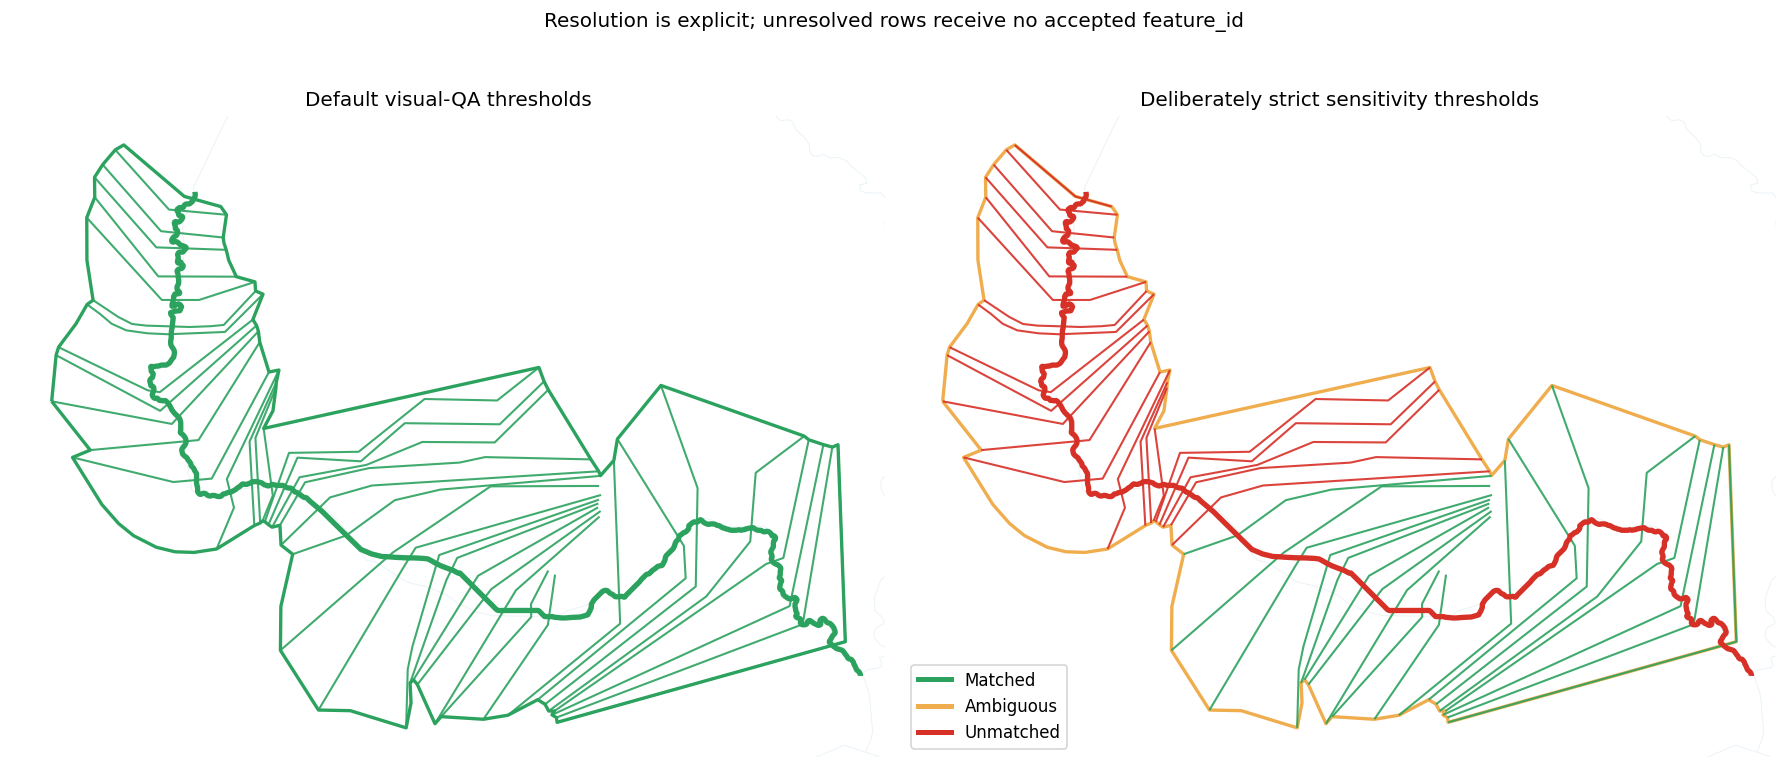

In [11]:
status_colors={"matched":"#2ca25f","ambiguous":"#f0ad4e","unmatched":"#d73027"}
def plot_status(ax, conflation, title):
    flowpaths_model.plot(ax=ax,color="#d8e8f0",linewidth=.55,alpha=.55)
    elements=conflation.matches.to_crs(model_crs)
    geometry_status = elements.loc[elements.element_type == "geometry", "status"].iloc[0]
    model_footprints.boundary.plot(
        ax=ax, color=status_colors[geometry_status], linewidth=2.0
    )
    for status in status_order:
        subset=elements.loc[(elements.element_type=="cross_section")&(elements.status==status)]
        if not subset.empty:
            subset.plot(ax=ax,color=status_colors[status],linewidth=1.25,alpha=.9)
    reach=elements.loc[elements.element_type=="reach"]
    reach.plot(ax=ax,color=[status_colors[s] for s in reach.status],linewidth=3.2)
    xmin,ymin,xmax,ymax=model_footprints.total_bounds
    xp,yp=(xmax-xmin)*.05,(ymax-ymin)*.05
    ax.set(xlim=(xmin-xp,xmax+xp),ylim=(ymin-yp,ymax+yp),aspect="equal")
    ax.set_axis_off()
    ax.set_title(title)
fig,axes=plt.subplots(1,2,figsize=(15,6.5),sharex=True,sharey=True)
plot_status(axes[0],result,"Default visual-QA thresholds")
plot_status(axes[1],strict_result,"Deliberately strict sensitivity thresholds")
axes[1].legend(handles=[Line2D([0],[0],color=c,lw=3,label=s.title())
                        for s,c in status_colors.items()],loc="lower left")
fig.suptitle("Resolution is explicit; unresolved rows receive no accepted feature_id",y=1.02)
plt.tight_layout()
plt.show()


## 6. Verify along-flowpath measures and XS sequence

Accepted XS links receive measure, fraction, distance from end, method, and
offset on each native NextGen feature. Because this HEC-RAS reach spans two
adjacent `wb-*` features, the audit also derives a continuous reviewer-only
reach-sequence fraction from the native per-feature measures.


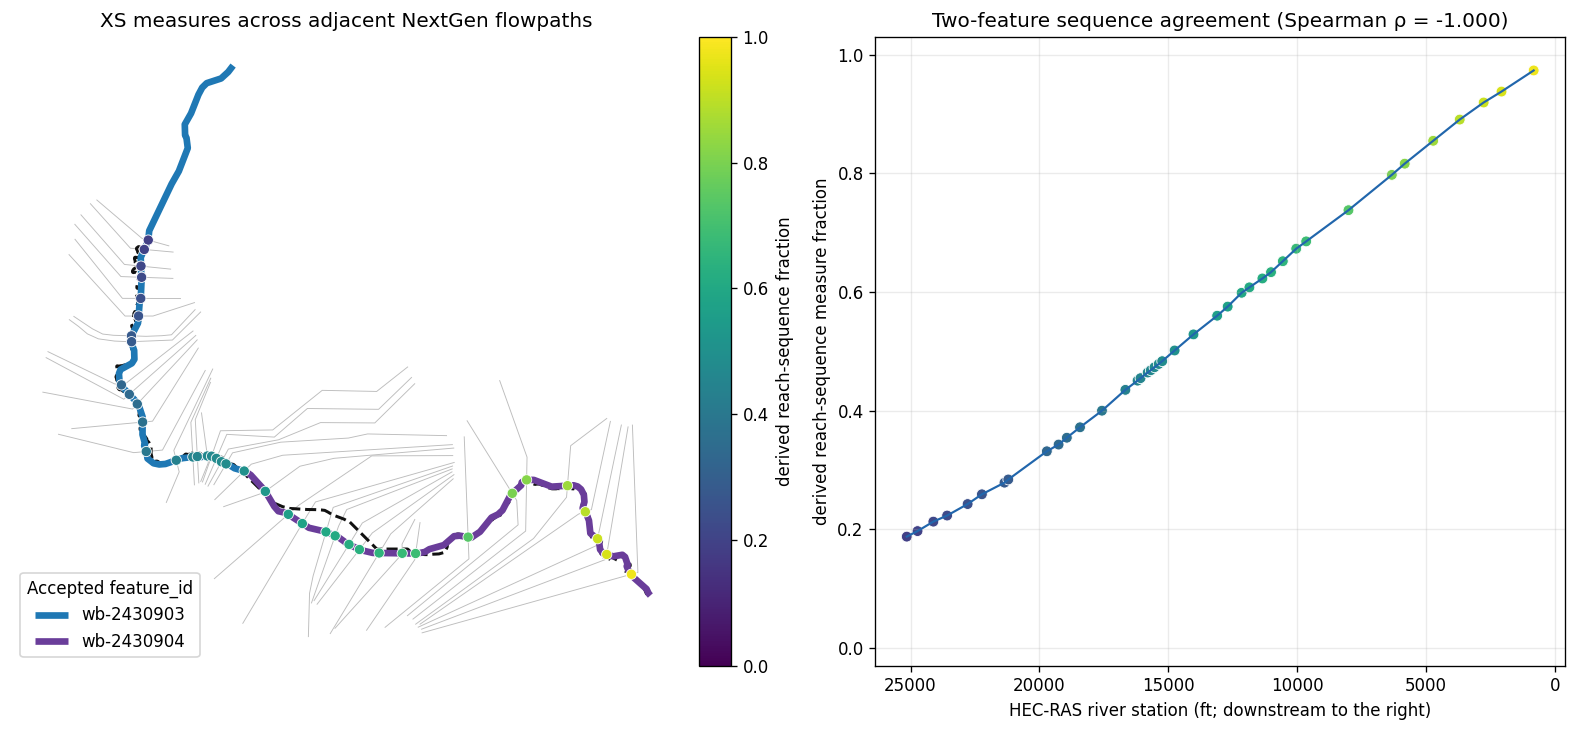

,xs_id,feature_id,flowpath_measure,flowpath_measure_fraction,flowpath_measure_from_end,measure_method,offset_distance,reach_sequence_measure_fraction
33,25147,wb-2430903,5171.410918,0.373366,8679.387487,intersection,0.0,0.187584
32,24729,wb-2430903,5428.774698,0.391947,8422.023707,intersection,0.0,0.196920
31,24115,wb-2430903,5868.528629,0.423696,7982.269776,intersection,0.0,0.212871
30,23581,wb-2430903,6151.387676,0.444118,7699.410729,intersection,0.0,0.223131
29,22786,wb-2430903,6685.343302,0.482668,7165.455102,intersection,0.0,0.242500
28,22233,wb-2430903,7138.935835,0.515417,6711.862570,intersection,0.0,0.258953
27,21356,wb-2430903,7680.010772,0.554481,6170.787633,intersection,0.0,0.278580
26,21208,wb-2430903,7827.801112,0.565152,6022.997292,intersection,0.0,0.283940
24,19714,wb-2430903,9138.173712,0.659758,4712.624693,intersection,0.0,0.331472
23,19258,wb-2430903,9450.705763,0.682322,4400.092642,intersection,0.0,0.342809


In [12]:
xs_matches = result.matches.loc[
    (result.matches.element_type == "cross_section")
    & (result.matches.status == "matched")
].copy()
xs_matches["river_station"] = pd.to_numeric(xs_matches.xs_id, errors="coerce")
xs_matches = xs_matches.sort_values("river_station", ascending=False)

flowpath_by_id = flowpaths_model.set_index(flowpaths_model.id.astype(str)).geometry
segment_review = (
    xs_matches.groupby("feature_id")
    .agg(xs_count=("xs_id", "size"), median_station=("river_station", "median"))
    .sort_values("median_station", ascending=False)
)
accepted_ids = segment_review.index.astype(str).tolist()
segment_lengths = {feature_id: flowpath_by_id.loc[feature_id].length for feature_id in accepted_ids}
segment_offsets = {}
running_length = 0.0
for feature_id in accepted_ids:
    segment_offsets[feature_id] = running_length
    running_length += segment_lengths[feature_id]

native_rho = {}
reach_sequence_measure = []
for _, row in xs_matches.iterrows():
    feature_id = str(row.feature_id)
    subset = xs_matches.loc[xs_matches.feature_id.astype(str) == feature_id]
    rho_feature = subset.river_station.corr(
        subset.flowpath_measure_fraction, method="spearman"
    )
    native_rho[feature_id] = rho_feature
    downstream_measure = (
        float(row.flowpath_measure)
        if rho_feature < 0
        else segment_lengths[feature_id] - float(row.flowpath_measure)
    )
    reach_sequence_measure.append(segment_offsets[feature_id] + downstream_measure)
xs_matches["reach_sequence_measure_fraction"] = np.asarray(reach_sequence_measure) / running_length

measure_points=gpd.GeoDataFrame(
    xs_matches.drop(columns="geometry"),
    geometry=[
        flowpath_by_id.loc[str(feature_id)].interpolate(float(measure))
        for feature_id, measure in zip(xs_matches.feature_id, xs_matches.flowpath_measure)
    ],
    crs=result.analysis_crs,
)
rho = xs_matches.river_station.corr(
    xs_matches.reach_sequence_measure_fraction, method="spearman"
)
fig,(amap,aseq)=plt.subplots(1,2,figsize=(15,6.2),gridspec_kw={"width_ratios":[1.35,1]})
cross_sections.plot(ax=amap,color="#bdbdbd",linewidth=.55)
centerlines.plot(ax=amap,color="#111111",linewidth=1.8,linestyle="--")
segment_colors = dict(zip(accepted_ids, ["#1f78b4", "#6a3d9a", "#33a02c", "#ff7f00"]))
for feature_id in accepted_ids:
    gpd.GeoSeries([flowpath_by_id.loc[feature_id]], crs=result.analysis_crs).plot(
        ax=amap, color=segment_colors[feature_id], linewidth=4,
        label=feature_id,
    )
scatter=amap.scatter(measure_points.geometry.x,measure_points.geometry.y,
                     c=measure_points.reach_sequence_measure_fraction,
                     cmap="viridis",vmin=0,vmax=1,
                     s=38,edgecolor="white",linewidth=.5,zorder=8)
amap.set_aspect("equal")
amap.set_axis_off()
amap.set_title("XS measures across adjacent NextGen flowpaths")
amap.legend(loc="lower left", title="Accepted feature_id")
fig.colorbar(scatter,ax=amap,fraction=.035,pad=.02,label="derived reach-sequence fraction")
aseq.plot(xs_matches.river_station,xs_matches.reach_sequence_measure_fraction,
          color="#2166ac",lw=1.3)
aseq.scatter(xs_matches.river_station,xs_matches.reach_sequence_measure_fraction,
             c=xs_matches.reach_sequence_measure_fraction,cmap="viridis",vmin=0,vmax=1,
             s=42,edgecolor="white",linewidth=.5)
aseq.invert_xaxis()
aseq.set_ylim(-.03,1.03)
aseq.grid(alpha=.25)
aseq.set_xlabel("HEC-RAS river station (ft; downstream to the right)")
aseq.set_ylabel("derived reach-sequence measure fraction")
aseq.set_title(f"Two-feature sequence agreement (Spearman ρ = {rho:.3f})")
plt.tight_layout()
plt.show()
display(xs_matches[["xs_id","feature_id","flowpath_measure","flowpath_measure_fraction",
                    "flowpath_measure_from_end","measure_method","offset_distance",
                    "reach_sequence_measure_fraction"]].head(12))


## 7. Review HUC intersections and output invariants

HUC intersections are separate from scoring. These checks verify the output
contract without asserting that an external feature must always win as USGS
data evolves.


In [13]:
huc_review=result.huc_intersections.drop(columns="geometry").copy()
huc_review["intersection_sq_miles"]=huc_review.intersection_area/(5280.0**2)
display(huc_review[["geometry_id","huc_id","intersection_sq_miles",
                    "geometry_area_fraction","huc_area_fraction"]])
assert result.candidates.confidence_score.between(0,1).all()
assert result.matches.loc[result.matches.status!="matched","feature_id"].isna().all()
assert result.matches.flowpath_measure_fraction.dropna().between(0,1).all()
assert result.huc_intersections.geometry_area_fraction.between(0,1).all()
display(pd.Series({
    "candidate scores bounded [0, 1]":True,
    "unresolved accepted feature_id values null":True,
    "measure fractions bounded [0, 1]":True,
    "HUC fractions bounded [0, 1]":True,
},name="passed").to_frame())


,geometry_id,huc_id,intersection_sq_miles,geometry_area_fraction,huc_area_fraction
0,lower-colorado-cummins-shiloh-branch,120903010507,2.888101,1.0,0.053936


,passed
"candidate scores bounded [0, 1]",True
unresolved accepted feature_id values null,True
"measure fractions bounded [0, 1]",True
"HUC fractions bounded [0, 1]",True


## Reviewer checklist and next steps

1. Confirm the model overlaps the NextGen `wb-*` flowpaths and `cat-*` catchments.
2. Compare ranks 1 and 2 with alternatives and inspect their direct XS intersections.
3. Confirm the winning score uses several independent evidence types.
4. Confirm unresolved rows have null accepted IDs but retain candidate evidence.
5. Confirm native XS measures form a continuous two-feature NextGen sequence.

This notebook deliberately calls `adapter="nextgen"` and preserves native
NextGen identifiers throughout. Production thresholds and weights belong to
the consuming workflow and are intentionally not encoded here.
